<div class= "alert alert-info">

**Lecture 6:**
> <u>We study how **circuits evolve in time** after an input.</u>
> <u>The key idea is that **energy storage leads to dynamics**.</u>

Lecture 7:
> We study how **circuits respond to different frequencies**.
> The key idea is that **circuits act as filters**.
    
</div>



# Lecture 6 — Circuit Dynamics (Time Domain)

## 1. Motivation

So far, we have studied circuits composed mainly of resistors and sources. 
**These systems are static: the output responds instantly to the input, with no time evolution.**

This changes when we introduce elements that store energy, such as capacitors and inductors.
**These elements give rise to dynamics: the response of the circuit now evolves in time.**

In this lecture, we study first- and second-order systems, meaning circuits with one or two energy storage elements.
Our goal is to understand how these systems respond to excitations and how their behavior depends on their physical parameters.

We want to understand how electrical circuits evolve in time after an input is applied.

**Core question:**
Given a circuit and an input, how do voltage and current change in time?

**Key idea:**
Dynamics arise from energy storage elements (capacitors and inductors).



## 2. Fundamental Elements (R, C, L)

* Resistor (R)
  * Relation: $V = RI$
  * Role: **Dissipates energy**
  * **Does not introduce dynamics.**
* Capacitor (C)
  * Relation: $I = C \frac{dV}{dt}$
  * Role: **Stores electric energy.**
* Inductor (L)
  * Relation: $V = L \frac{dI}{dt}$
  * Role: **Stores magnetic energy**

> Key Insight: 
> **Only C and L introduce time dependence** → they create circuit dynamics.


<br>
<br>


## 3. First-Order Systems

<div class="alert alert-info">

> Definition:
> **A system is first-order if it contains one energy storage element.**


Typical systems are RC or RL with one energy source (electric in RC or magnetic in RL).

* **Energy Perspective**
    * Capacitor: $E=\frac{1}{2} C\, V^2$
    * Inductor: $E=\frac{1}{2} L\, i^2$

    **Dynamics = energy stored and released over time**


* <u>All first-order systems follow:</u>
    $$ \boxed{\frac{dx}{dt} + \frac{x}{\tau} = \text{input}} $$
    **All first-order systems exhibit exponential dynamics**

* **Time Constant $\tau$** 
    * Measures how fast the system responds
    * Small $\tau$ → fast system
    * Large $\tau$ → slow system

</div>

<br>
<br>


### RC Circuit

<img src="../figs/lec5/RC.svg" align="center" width="300"/>

* **Differential equation:**
    From KVL and KCL (Kirchhoff's laws) we have:
    $$ V_{\rm in} = v_R(t) + v_C(t), \quad v_R(t) = R i(t), \quad i(t)=C \frac{dv_C}{dt} $$
    where $V_{\rm in}$ is the voltage of the source and we obtain:
    $$ \boxed{ R C \frac{dv_C}{dt} + v_C(t) = V_{\rm in}} $$

* <u>Solution: **Exponential Behavior**.</u>
  In case of charging C, $v_C(t=0)=0$ and the source has fixed foltage $V_{\rm in}=V_0$ and the circuit is closed at $t=0$. One obtains:
    $$ \boxed{v_C(t) = V_0 \left(1 - e^{-t/RC} \right)} \quad \boxed{i(t) = \frac{V_0}{R} e^{-t/RC}} $$
* **Time constant:** $\tau = R C$
* At $t = \tau$ → system reaches $(1-e^{-1})\approx 63\%$ of final value.

<br>
<br>

<u>**What to Observe**</u>
* Increasing $R$ or $C$ → **slower response**
* **Response is exponential**
* **No oscillations**


<function matplotlib.pyplot.show(close=None, block=None)>

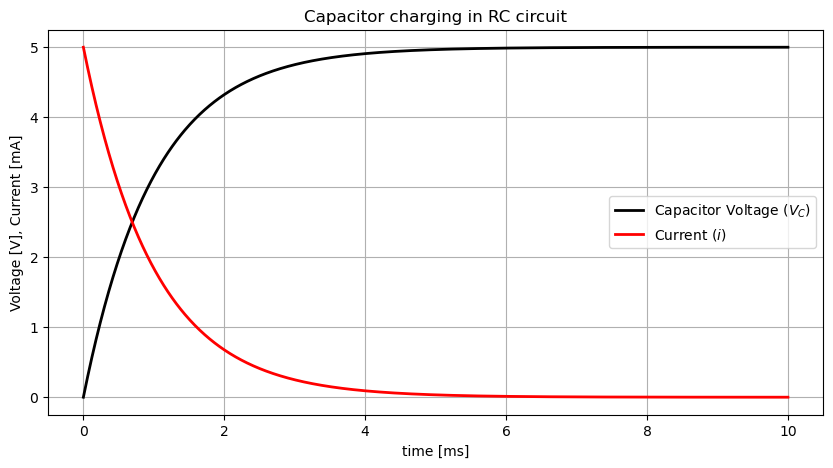

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parametrat
V0 = 5  # Volt
R = 1000  # Ohm
C = 1e-6  # Farad
tau = R*C
t = np.linspace(0, 0.01, 1000)

# Voltage and Current
v_C = V0*(1 - np.exp(-t/tau))
i = (V0/R)*np.exp(-t/tau)

# Plots
plt.figure(figsize=(10,5))
plt.plot(1e3*t, v_C,'-k',lw=2, label=r'Capacitor Voltage ($V_C$)')
plt.plot(1e3*t, 1e3*i,'-r',lw=2, label=r'Current ($i$)')
plt.xlabel('time [ms]')
plt.ylabel('Voltage [V], Current [mA]')
plt.title('Capacitor charging in RC circuit')
plt.grid(True)
plt.legend()
plt.show

<br>
<br>
<br>

### RL Circuit

<img src="../figs/lec5/RL.svg" align="center" width="300"/>

* Same mathematical structure
  $$ V_{\rm in} = v_R(t) + v_L(t), \quad v_R(t) = R i(t), \quad v_L(t)=L\frac{di}{dt} $$
  $$ \boxed{\frac{L}{R}\frac{di}{dt} + i(t) = \frac{V_{\rm in}}{R}} $$

* <u>Solution: **Exponential Behavior**.</u>
  When sudenly close the circuit, current changes from $i(t=0)=0$ to the maximum allowed $I_0=V_{\rm in}/R=V_0/R$. Therefore,
    $$ \boxed{i(t) = I_0 \left(1 - e^{-t/\tau} \right)}$$

* Time constant: $\tau = L/R$

RL circuit has the same structure as RC circuit. Current builds gradually due to inductance.


* **What to Observe**
  * Increasing $L$ → slower response
  * Increasing $R$ → faster damping
  * Still exponential behavior


### Key Insight
**Both RC and RL circuits exhibit exponential response governed by a single time constant.**

<br>


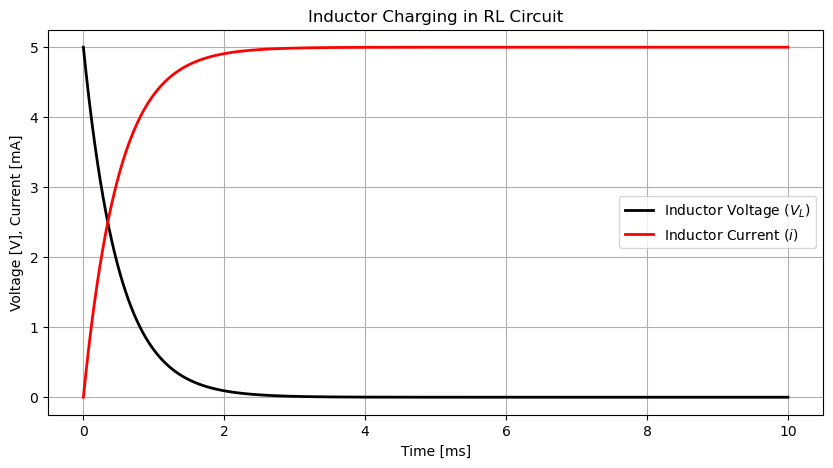

In [7]:
# Parameters
V0 = 5  # Volt
R = 1000  # Ohm
L = 0.5  # Henry
tau = L/R
t = np.linspace(0, 0.01, 1000)

# Current and Voltage
i_L = (V0/R)*(1 - np.exp(-t/tau))
v_L = V0 * np.exp(-t/tau)

# Plots
plt.figure(figsize=(10,5))
plt.plot(1e3*t, v_L,'-k',lw=2, label=r'Inductor Voltage ($V_L$)')
plt.plot(1e3*t, 1e3*i_L,'-r',lw=2, label=r'Inductor Current ($i$)')
plt.xlabel('Time [ms]')
plt.ylabel('Voltage [V], Current [mA]')
plt.title('Inductor Charging in RL Circuit')
plt.grid(True)
plt.legend()
plt.show()


<br>
<br>
<br>


## 5. Second-Order Systems (RLC)

<div class="alert alert-info">

> Definition:
> **A system is second-order if it contains two energy storage elements.**


Typical systems are LC or more general RLC circuits. Exchange of energy between the two sources can produce oscillations.


* <u>All second-order systems follow:</u>
    $$ \boxed{\frac{d^2x}{dt^2} + 2\gamma\frac{dx}{dt} + \omega_0^2 x = \text{input}} $$
    where:
    * $\omega_0$ is the natural frequency of the system
    * $\gamma$ is the damping factor.

##### Regimes of Behavior (Response of the System)
* **Underdamped** ($\gamma < \omega_0$)
    * **Oscillatory response**
    * Energy exchanges between L and C
* **Critically Damped** ($\gamma = \omega_0$)
    * Fastest return to equilibrium
    * No oscillation
* **Overdamped** ($\gamma > \omega_0$)
    * Slow decay
    * No oscillation

##### Physical Picture
* Capacitor ↔ electric energy
* Inductor ↔ magnetic energy
* Resistor → dissipates energy

**System behavior = balance between energy exchange and dissipation**

</div>

<br>
<br>



### RLC circuit (in series)

<img src="../figs/lec5/RLC_seri.svg" align="center" width=500/>

**Differential Equation**
From KVL:
$$ V_{\rm in}(t) = v_R(t) + v_L(t) + v_C(t) $$
$$ V_{\rm in}(t) = R i(t) + L\frac{di(t)}{dt} + \frac{1}{C}\int i(t) dt $$

write current $i(t) = dq(t)/dt$, where $q(t)$ is the charge that flows through, we obtain:
$$ \boxed{L\frac{d^2q}{dt^2} + R \frac{dq}{dt} + \frac{1}{C} q = V_{\rm in}} $$

Standard second-order form.

### Regimes

* Underdamped → oscillatory behavior
* Critically damped → fastest non-oscillatory response
* Overdamped → slow decay



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# function that computes current
def rlc_current(R, L, C):
    V0 = 10  # Amplitude of the source (Volt)
    C  *= 1e-6 # Convert microFarad in Farad
    f = np.logspace(1, 4, 1000)  # Frequency (Hz)
    omega = 2 * np.pi * f

    Z = R + 1j * (omega * L - 1/(omega * C))
    I = V0 / np.abs(Z)

    plt.figure(figsize=(9,5))
    plt.plot(f, I, '-k', lw=2)
    plt.title('Response in frequency of the RLC circuit')
    plt.xlabel('Frekuency [Hz]')
    plt.ylabel('Current [A]')
    plt.grid(True)
    plt.ylim(0, np.max(I)*1.1)
    plt.xscale('log')
    plt.show()

# Interactive Sliders for R, L and C
interact(rlc_current,
         R=FloatSlider(min=10, max=1000, step=10, value=100, description=r'$R (\Omega)$'),
         L=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1, description=r'$L (H)$'),
         C=FloatSlider(min=0.1, max=100, step=0.1, value=10, description=r'$C (\mu F)$')
        );

interactive(children=(FloatSlider(value=100.0, description='$R (\\Omega)$', max=1000.0, min=10.0, step=10.0), …


### Physical Picture

* Energy exchange between L and C
* Resistance dissipates energy



## 6. Simulation & Observation

For each simulation (RC, RL, RLC), identify:
* Time constant or oscillation frequency
* Type of response (exponential vs oscillatory)
* Effect of parameters

<u>Typical Observations:</u>
* **Increasing $R$ → more damping**
* **Increasing $C$ or $L$ → slower dynamics**
* **RLC → oscillate only if damping is low**


## 7. Summary

* **Resistor → no dynamics (only dissipation)**
* **Capacitor & Inductor → create dynamics**
* **First-order systems → exponential response**
* **Second-order systems → oscillations + damping**
* **System order = number of energy storage elements**
* RC/RL → exponential dynamics
* RLC → oscillations + damping



<br>
<br>
<br>

<div style="border:6px solid #f00; background-color:#fff; color:#000; border-radius: 5px; padding: 10px;">

# Optional Reading: Memristor — The Fourth Element

<img src="../figs/lec5/Two-terminal_non-linear_circuit_elements.svg" align="center" width=500/>

In classical circuit theory, we have three fundamental elements:
- Resistor (R): relates voltage and current  
- Capacitor (C): relates voltage and charge  
- Inductor (L): relates current and magnetic flux  

There is also a fourth predicted element:

### Memristor (M)
- Relates: **charge ($q$)** and **magnetic flux ($\varphi$)**  
- Idea: a <u>**resistor with memory**</u>


### Physical Behavior (Intuitive)
- Its resistance depends on the history of current  
- When current stops → the state is **preserved** (resistance)
- Therefore: a **non-volatile** component (memory without energy source)


### Why is it interesting?
- Predicted by **Leon Chua (1971)**  
- Experimentally realized around **2008 (HP Labs)**  
- Potential applications:
  - **non-volatile memory** 
  - **neuromorphic systems (mimicking real synapses)**
  - **hardware for AI**  


### For this course
We will focus only on **R, L, and C**.  
The memristor is a **modern example** showing that circuit theory is still evolving.


Ref: [HP 2008 Nature paper](https://web.ece.ucsb.edu/~strukov/papers/2008/Nature2008.pdf), [Wikipedia](https://en.wikipedia.org/wiki/Memristor)

</div>



<br>
<br>
<br>


<div style="border:6px solid #f00; background-color:#111; color:#fff; border-radius: 5px; padding: 10px;">

## Optional Reading: Laplace Transform & Generalized Impedance

### Core Idea

When analyzing circuits, we often get **differential equations** (due to C and L).

The Laplace transform converts them into **algebraic equations**, which are much easier to solve.


### Key Result

In the Laplace domain (variable $s$), circuit elements behave like:

- Resistor: $Z_R = R$  
- Capacitor: $Z_C = \frac{1}{sC}$  
- Inductor: $Z_L = sL$  

This allows us to treat circuits like simple **algebraic networks**.


### Why this is powerful

- Differential equations → algebra  
- Initial conditions can be included naturally  
- Works for **any input** (not only sinusoidal)  


### Physical Meaning

The Laplace variable:
$$
s = \sigma + j\omega
$$

- $\sigma$ → transient (exponential decay/growth)  
- $\omega$ → oscillation (frequency)  

Laplace captures **both transient and steady-state behavior**.


### Connection to AC Analysis

After a long time ($t \gg \tau$), transients vanish:

$$
s \rightarrow j\omega
$$

Laplace reduces to **Fourier (AC) analysis**.


### For this course

We will **not use full Laplace calculations**.

We use it only to understand:
- where impedance comes from  
- why AC analysis works  

</div>